In [30]:
import torch as t
from torch import nn

device = 'cuda' if t.cuda.is_available() else 'cpu'
print('device:', device)
test_in = t.rand(3, 32, 32)
print(test_in.shape)

device: cuda
torch.Size([3, 32, 32])


In [31]:
# (32+2*0*(4-1)-1) / 4 + 1
conv = nn.Conv2d(3, 3, kernel_size=4, stride=4, padding=0)
test_out = conv(test_in)
print(test_out.shape)

torch.Size([3, 8, 8])


In [32]:
import torch
import torch.nn as nn

# Định nghĩa Stem Conv2D
stem_conv = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=4, stride=4, padding=0)

# Tạo ảnh giả lập 32x32
input_image = torch.randn(1, 3, 32, 32)

# Tính đầu ra
output = stem_conv(input_image)
total_tokens = output.shape[2] * output.shape[3]

print(f"Kích thước grid: {output.shape[2]}x{output.shape[3]}")
print(f"Tổng số token: {total_tokens}")

Kích thước grid: 8x8
Tổng số token: 64


In [21]:
import torch

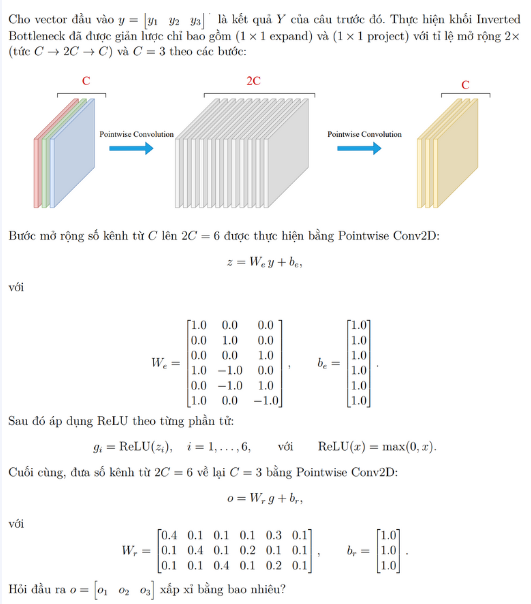

In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class InvertedBottleneckBlock(nn.Module):
    def __init__(self, W_e, b_e, W_r, b_r):
        super(InvertedBottleneckBlock, self).__init__()

        # Lấy thông số C từ ma trận trọng số
        self.out_channels_exp = W_e.shape[0] # 6
        self.in_channels = W_e.shape[1]      # 3

        # 1. Expansion Layer (1x1 Conv)
        self.expansion = nn.Conv2d(self.in_channels, self.out_channels_exp,
                                kernel_size=1, bias=True)

        # 2. Projection Layer (1x1 Conv)
        self.projection = nn.Conv2d(self.out_channels_exp, self.in_channels,
                                    kernel_size=1, bias=True)

        # Gán trọng số cứng từ đề bài vào các lớp
        with torch.no_grad():
            self.expansion.weight.copy_(W_e)
            self.expansion.bias.copy_(b_e)
            self.projection.weight.copy_(W_r)
            self.projection.bias.copy_(b_r)

    def forward(self, x):
        # Bước 1: Mở rộng số kênh từ C lên 2C
        x = self.expansion(x)

        # Bước 2: Kích hoạt phi tuyến ReLU
        x = F.relu(x)

        # Bước 3: Nén số kênh từ 2C về lại C
        x = self.projection(x)

        return x

# --- Chuẩn bị dữ liệu ---
# Ma trận W_e (6, 3, 1, 1)
W_e = torch.tensor([
    [1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0],
    [1.0, -1.0, 0.0], [0.0, -1.0, 1.0], [1.0, 0.0, -1.0]
]).view(6, 3, 1, 1)

# Ma trận W_r (3, 6, 1, 1)
W_r = torch.tensor([
    [0.4, 0.1, 0.1, 0.1, 0.3, 0.1],
    [0.1, 0.4, 0.1, 0.2, 0.1, 0.1],
    [0.1, 0.1, 0.4, 0.1, 0.2, 0.1]
]).view(3, 6, 1, 1)

b_e = torch.ones(6)
b_r = torch.ones(3)

# Khởi tạo model
model = InvertedBottleneckBlock(W_e, b_e, W_r, b_r)

# Input y = [2, -1, 3] đưa về shape (Batch, Channel, H, W)
y_in = torch.tensor([2.0, -1.0, 3.0]).view(1, 3, 1, 1)

# Thực thi
output = model(y_in)
print("Kết quả o1, o2, o3:\n", output.squeeze())

Kết quả o1, o2, o3:
 tensor([4.5000, 3.0000, 4.3000], grad_fn=<SqueezeBackward0>)


In [18]:
def levenshtein_distance(s1, s2):
    if len(s1) > len(s2):
        s1, s2 = s2, s1

    distances = range(len(s1) + 1)
    for i2, c2 in enumerate(s2):
        distances_ = [i2+1]
        for i1, c1 in enumerate(s1):
            if c1 == c2:
                distances_.append(distances[i1])
            else:
                distances_.append(1 + min((distances[i1], distances[i1 + 1], distances_[-1])))
        distances = distances_
    return distances[-1]

s1 = "danger_zone"
s2 = "dangerous"
levenshtein_distance(s1, s2)

4

In [37]:
import numpy as np

# 1. Setup Input Tensors (H x W x C)
# Each channel is a 2x2 matrix
x0 = np.array([[0.6, 0.8], [0.0, 0.0]])
x1 = np.array([[0.9, 1.2], [0.0, 0.0]])
x2 = np.array([[0.5, 0.0], [1.2, 0.0]])

# Stack channels to create a (2, 2, 3) tensor
x = np.stack([x0, x1, x2], axis=-1)

# Hyperparameters
gamma = 0.5
beta = 0.1

# 2. Step-by-step GRN Calculation
# Step 2.1: Compute L2 Norm per channel (g_c)
# Sum squares over H and W, then take square root
g = np.sqrt(np.sum(x**2, axis=(0, 1)))
print(g.shape)

# Step 2.2: Compute Global Average Intensity (mean(g))
mean_g = np.mean(g)
print(mean_g.shape)

# Step 2.3: Compute Channel Weighting (n_c)
n = g / mean_g

# 3. Compute Final Output (x_out)
# Formula: x_out = x + gamma * (x * n) + beta
# n is broadcasted across height and width dimensions
x_out = x + gamma * (x * n) + beta

# 4. Extract Results at (0, 0) for each channel
results_00 = x_out[0, 0, :]

print(f"L2 Norms (g): {g}")
print(f"Mean(g): {mean_g:.4f}")
print(f"Normalization Factors (n): {n}")
print("-" * 30)
print(f"Final values at (0,0):")
print(f"Channel 0: {results_00[0]:.2f}")
print(f"Channel 1: {results_00[1]:.2f}")
print(f"Channel 2: {results_00[2]:.2f}")

(3,)
()
L2 Norms (g): [1.  1.5 1.3]
Mean(g): 1.2667
Normalization Factors (n): [0.78947368 1.18421053 1.02631579]
------------------------------
Final values at (0,0):
Channel 0: 0.94
Channel 1: 1.53
Channel 2: 0.86


In [39]:
X_path = torch.tensor([1, 2, 3, 1])
W = torch.tensor([[1, 0, 1],
                [0, 1, 1],
                [1, 1, 0],
                [1, 0, -1],])

print(X_path @ W)
print((X_path @ W).shape)


tensor([5, 5, 2])
torch.Size([3])


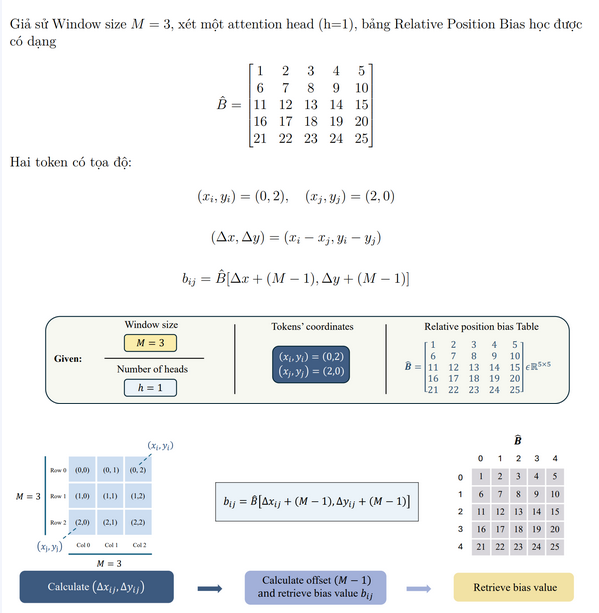

In [ ]:
import torch
import torch.nn as nn

# Định nghĩa Stem Conv2D
stem_conv = nn.Conv2d(in_channels=3, out_channels=3, kernel_size=64, stride=8, padding=0)

# Tạo ảnh giả lập 32x32
input_image = torch.randn(1, 3, 640, 640)
input_image2 = torch.randn(1, 3, 320, 320)
input_image3 = torch.randn(1, 3, 160, 160)

# Tính đầu ra
output = stem_conv(input_image)
total_tokens = output.shape[2] * output.shape[3]

print(f"Kích thước grid: {output.shape[2]}x{output.shape[3]}")
print(f"Tổng số token: {total_tokens}")

output = stem_conv(input_image2)
total_tokens = output.shape[2] * output.shape[3]

print(f"Kích thước grid: {output.shape[2]}x{output.shape[3]}")
print(f"Tổng số token: {total_tokens}")

output = stem_conv(input_image3)
total_tokens = output.shape[2] * output.shape[3]

print(f"Kích thước grid: {output.shape[2]}x{output.shape[3]}")
print(f"Tổng số token: {total_tokens}")

#? Note: 1 x conv2d() ~ 1 pixel

Kích thước grid: 73x73
Tổng số token: 5329
Kích thước grid: 33x33
Tổng số token: 1089
Kích thước grid: 13x13
Tổng số token: 169


In [46]:
# (5, 28, 28), (5, 14, 14), (5, 7, 7).

import numpy as np

def calculate_iou(box1, box2):
    """
    Computes IoU between two boxes: [x1, y1, x2, y2]
    """
    # Determine the coordinates of the intersection rectangle
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])

    if x_right < x_left or y_bottom < y_top:
        return 0.0

    # Calculate area of intersection
    intersection_area = (x_right - x_left) * (y_bottom - y_top)

    # Calculate area of union
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union_area = float(box1_area + box2_area - intersection_area)

    return intersection_area / union_area

# Example usage:
boxA = [0.5, 0.5]
boxB = [0.55, 0.55]
print(f"IoU: {calculate_iou(boxA, boxB)}")

boxA = [0.48, 0.52]
boxB = [0.5, 0.5]
print(f"IoU: {calculate_iou(boxA, boxB)}")

IndexError: list index out of range

In [ ]:
# 1 - (5, 28, 28),
# 2- (5, 14, 14),
# 3 - (5, 7, 7).

In [ ]:
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

# 1. Setup dữ liệu đầu vào theo đề bài
# Độ dài thực của 3 câu: L1=3, L2=5, L3=2
lengths = torch.tensor([3, 5, 2])
max_len = lengths.max().item() # 5
batch_size = len(lengths)
emb_dim = 4    # Giả sử số chiều Embedding là 4
hidden_dim = 8 # Giả sử số chiều Hidden là 8

# Tạo batch ảo với padding (Batch, Max_Len, Emb_Dim)
# Lưu ý: PyTorch yêu cầu batch phải được sắp xếp theo độ dài giảm dần khi dùng pack_padded_sequence (với enforce_sorted=True)
lengths_sorted, sorted_indices = lengths.sort(descending=True)
# sorted_lengths: [5, 3, 2]

input_batch = torch.randn(batch_size, max_len, emb_dim) # type: ignore
# Sắp xếp lại batch theo thứ tự giảm dần của độ dài
input_batch = input_batch[sorted_indices]

print(f"--- 1. Dense Vectors Shape (Batch, Max_Len, Emb_Dim) ---")
print(input_batch.shape) # [3, 5, 4]

# 2. Bước: pack_padded_sequence()
# Loại bỏ padding, 'flatten' batch thành các token thực
packed_input = pack_padded_sequence(input_batch, lengths_sorted, batch_first=True)

print(f"\n--- 2. Packed Sequence (Input) ---")
print(f"Tổng số non-pad tokens: {packed_input.data.shape[0]}") # 3 + 5 + 2 = 10
print(f"Shape: {packed_input.data.shape}") # [10, 4]

# 3. Bước: Qua mạng RNN (Bi-directional)
# Giả sử dùng Bi-LSTM
rnn = nn.LSTM(emb_dim, hidden_dim, batch_first=True, bidirectional=True)
packed_output, (hn, cn) = rnn(packed_input)

print(f"\n--- 3. Packed Sequence (Output) ---")
# Kích thước tăng gấp đôi do Bi-directional (2 * Hidden_Dim)
print(f"Shape: {packed_output.data.shape}") # [10, 16]

# 4. Bước: pad_packed_sequence()
# Đưa dữ liệu trở lại dạng tensor có padding ban đầu
output_padded, output_lengths = pad_packed_sequence(packed_output, batch_first=True)

print(f"\n--- 4. Final Padded Output Shape ---")
print(output_padded.shape) # [3, 5, 16]

--- 1. Dense Vectors Shape (Batch, Max_Len, Emb_Dim) ---
torch.Size([3, 5, 4])

--- 2. Packed Sequence (Input) ---
Tổng số non-pad tokens: 10
Shape: torch.Size([10, 4])

--- 3. Packed Sequence (Output) ---
Shape: torch.Size([10, 16])

--- 4. Final Padded Output Shape ---
torch.Size([3, 5, 16])


In [ ]:
import torch
import torch.nn as nn

# Cấu hình từ đề bài
B = 4           # Batch size
H, W = 224, 224 # Input image
P = 16          # Patch size
L = 25          # Text length
D_in = 768      # Encoder output dim
D_hidden = 384  # Hidden/Projection dim

print(f"--- THÔNG SỐ ĐẦU VÀO ---")
print(f"Batch size: {B}, Image: {H}x{W}, Patch: {P}x{P}, Text Len: {L}\n")

# 1. VISUAL PATHWAY
print("--- VISUAL PATHWAY ---")
# Step 1: Patch Embedding
num_patches = (H // P) * (W // P) # (224/16) * (224/16) = 14 * 14 = 196
vision_features = torch.randn(B, num_patches, D_in)
print(f"Step 1 (Patch Embedding): [{B}, {num_patches}, {D_in}]")

# Step 2: Linear Projection (768 -> 384)
proj_v = nn.Linear(D_in, D_hidden)
vision_proj = proj_v(vision_features)
print(f"Step 2 (Linear Projection): [{B}, {num_patches}, {D_hidden}]")

# Step 3: Mean Pooling (theo trục token/patch)
vision_pooled = torch.mean(vision_proj, dim=1)
print(f"Step 3 (Mean Pooling): [{B}, {D_hidden}]")


# 2. TEXT PATHWAY
print("\n--- TEXT PATHWAY ---")
# Step 4: Text Encoder output
text_features = torch.randn(B, L, D_in)
print(f"Step 4 (Text Encoder): [{B}, {L}, {D_in}]")

# Step 5: Linear Projection (768 -> 384)
proj_t = nn.Linear(D_in, D_hidden)
text_proj = proj_t(text_features)
print(f"Step 5 (Linear Projection): [{B}, {L}, {D_hidden}]")

# Step 6: Masked Mean Pooling (theo trục token)
text_pooled = torch.mean(text_proj, dim=1)
print(f"Step 6 (Mean Pooling): [{B}, {D_hidden}]")


# 3. CONCATENATION & MLP HEAD
print("\n--- CONCATENATION & MLP HEAD ---")
# Step 7: Concat theo trục feature
combined = torch.cat([vision_pooled, text_pooled], dim=-1)
print(f"Step 7 (Concat): [{B}, {D_hidden * 2}] -> [{B}, {combined.shape[1]}]")

# Step 8: MLP Layer 1 (Linear 768 -> 384)
mlp1 = nn.Linear(combined.shape[1], D_hidden)
out_mlp1 = mlp1(combined)
print(f"Step 8 (MLP Layer 1): [{B}, {D_hidden}]")

# Step 9: MLP Layer 2 (Linear 384 -> 384)
mlp2 = nn.Linear(D_hidden, D_hidden)
out_mlp2 = mlp2(out_mlp1)
print(f"Step 9 (MLP Layer 2): [{B}, {D_hidden}]")

# Step 10: MLP Layer 3 (Linear 384 -> 4)
mlp3 = nn.Linear(D_hidden, 4)
bbox = mlp3(out_mlp2)
print(f"Step 10 (MLP Layer 3): [{B}, 4]")

Kích thước đặc trưng ảnh sau Pooling: torch.Size([4, 768])
Kích thước đặc trưng văn bản sau Pooling: torch.Size([4, 768])
Đầu ra cuối cùng (Bbox coordinates): torch.Size([4, 4])
Giá trị dự đoán cho ảnh đầu tiên:
tensor([-0.0115,  0.0079,  0.0178, -0.0256], grad_fn=<SelectBackward0>)
